# 第 9 章 · Causal Attention 与词 Bigram LM 代码实验

本页把下一词预测拆成两件事：因果注意力只能看左侧上下文，bigram 统计给出最简单的下一词分布。

[章节网页](../ch9.html)

## 运行内容

- 计算 causal attention
- 统计词 bigram
- 绘制 attention 热力图

## 0. 因果注意力

因果 mask 会遮住当前位置右侧的词。热力图中右上角为 0，说明模型不能偷看未来。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 加入 causal mask 后，每个位置只能看见自己和左侧 token。
lm_tokens = "to be or not to be".split()
X_lm = np.array([
    [0.7, 0.1, 0.1],
    [0.2, 0.8, 0.2],
    [0.4, 0.3, 0.6],
    [0.3, 0.7, 0.3],
    [0.7, 0.1, 0.1],
    [0.2, 0.8, 0.2],
])
scores_lm = X_lm @ X_lm.T / math.sqrt(X_lm.shape[1])
mask = np.triu(np.ones_like(scores_lm), k=1).astype(bool)
scores_lm = np.where(mask, -1e9, scores_lm)
weights_lm = np.exp(scores_lm - scores_lm.max(axis=1, keepdims=True))
weights_lm = weights_lm / weights_lm.sum(axis=1, keepdims=True)

display(pd.DataFrame(np.round(weights_lm, 3), index=lm_tokens, columns=lm_tokens))

,to,be,or,not,to,be
to,1.000,0.000,0.000,0.000,0.000,0.000
be,0.431,0.569,0.000,0.000,0.000,0.000
or,0.313,0.326,0.360,0.000,0.000,0.000
not,0.218,0.270,0.244,0.268,0.000,0.000
to,0.214,0.183,0.198,0.191,0.214,0.000
be,0.142,0.187,0.159,0.183,0.142,0.187


## 1. 下一词统计

bigram 只根据当前词预测下一个词。它很简单，但能帮助读者理解语言模型的条件概率视角。

In [3]:
# 词 bigram：根据当前词统计下一个词分布。
text = "to be or not to be that is the question to be".split()
bigram = defaultdict(Counter)
for a, b in zip(text, text[1:]):
    bigram[a][b] += 1

lm_rows = []
for token, counts in bigram.items():
    total = sum(counts.values())
    best_next, best_count = counts.most_common(1)[0]
    lm_rows.append({
        "当前词": token,
        "最可能下一个词": best_next,
        "概率": round(best_count / total, 3),
        "候选分布": dict(counts),
    })

display(pd.DataFrame(lm_rows))

,当前词,最可能下一个词,概率,候选分布
0,to,be,1.0,{'be': 3}
1,be,or,0.5,"{'or': 1, 'that': 1}"
2,or,not,1.0,{'not': 1}
3,not,to,1.0,{'to': 1}
4,that,is,1.0,{'is': 1}
5,is,the,1.0,{'the': 1}
6,the,question,1.0,{'question': 1}
7,question,to,1.0,{'to': 1}


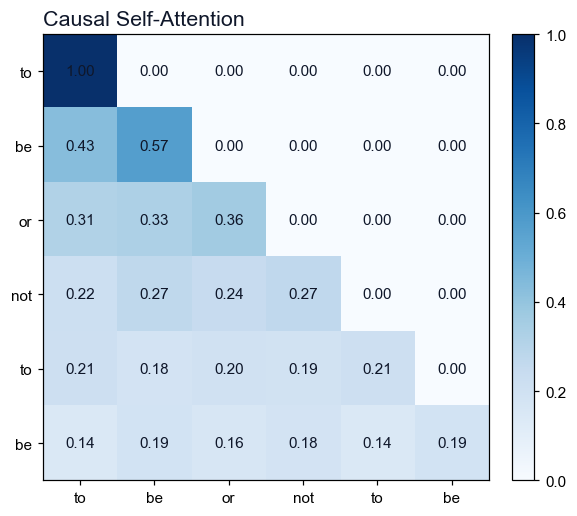

In [4]:
# 绘制 causal attention 热力图。
fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(weights_lm, cmap="Blues", vmin=0, vmax=weights_lm.max())
ax.set_xticks(range(len(lm_tokens)), lm_tokens)
ax.set_yticks(range(len(lm_tokens)), lm_tokens)
for i in range(len(lm_tokens)):
    for j in range(len(lm_tokens)):
        ax.text(j, i, f"{weights_lm[i, j]:.2f}", ha="center", va="center", color="#0f172a")
ax.set_title("Causal Self-Attention", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()